In [ ]:
!pip install reportlab
!pip install easyocr
!pip install -U python-doctr[torch]
!pip install opencv-python numpy matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 38.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 422.9/422.9 kB 34.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 292.9/292.9 kB 24.7 MB/s eta 0:00:00


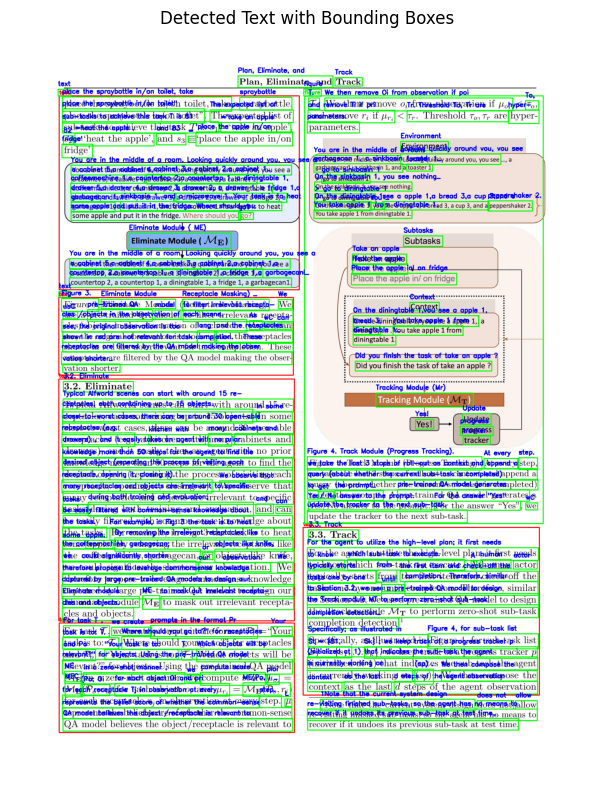

In [ ]:
import cv2
import easyocr
import matplotlib.pyplot as plt

# Initialize EasyOCR Reader
reader = easyocr.Reader(['en'])

# Load Image
image_path = "/content/output_bbox.png"
image = cv2.imread(image_path)

# Perform OCR
results = reader.readtext(image)

# Draw Bounding Boxes
for (bbox, text, prob) in results:
    # Extract coordinates
    top_left, top_right, bottom_right, bottom_left = bbox
    top_left = tuple(map(int, top_left))
    bottom_right = tuple(map(int, bottom_right))

    # Draw rectangle around text
    cv2.rectangle(image, top_left, bottom_right, (0, 255, 0), 2)

    # Put extracted text near the bounding box
    cv2.putText(image, text, (top_left[0], top_left[1] - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)

# Convert BGR to RGB for Matplotlib display
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Show Image with Bounding Boxes
plt.figure(figsize=(10, 10))
plt.imshow(image_rgb)
plt.axis("off")
plt.title("Detected Text with Bounding Boxes")
plt.show()


In [ ]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/gpu
!pip install easyocr
!pip install reportlab
!pip install pdf2docx


Found existing installation: torch 2.6.0+cpu
Uninstalling torch-2.6.0+cpu:
  Successfully uninstalled torch-2.6.0+cpu
Found existing installation: torchvision 0.21.0+cpu
Uninstalling torchvision-0.21.0+cpu:
  Successfully uninstalled torchvision-0.21.0+cpu
Found existing installation: torchaudio 2.6.0+cpu
Uninstalling torchaudio-2.6.0+cpu:
  Successfully uninstalled torchaudio-2.6.0+cpu
Found existing installation: easyocr 1.7.2
Uninstalling easyocr-1.7.2:
  Successfully uninstalled easyocr-1.7.2
Looking in indexes: https://download.pytorch.org/whl/cpu
  Using cached https://download.pytorch.org/whl/cpu/torch-2.6.0%2Bcpu-cp311-cp311-linux_x86_64.whl.metadata (26 kB)
  Using cached https://download.pytorch.org/whl/cpu/torchvision-0.21.0%2Bcpu-cp311-cp311-linux_x86_64.whl.metadata (6.1 kB)
  Using cached https://download.pytorch.org/whl/cpu/torchaudio-2.6.0%2Bcpu-cp311-cp311-linux_x86_64.whl.metadata (6.6 kB)
Using cached https://download.pytorch.org/whl/cpu/torch-2.6.0%2Bcpu-cp311-cp311

  Using cached easyocr-1.7.2-py3-none-any.whl.metadata (10 kB)
Using cached easyocr-1.7.2-py3-none-any.whl (2.9 MB)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 4.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.0/132.0 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.0/20.0 MB 82.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 244.3/244.3 kB 22.9 MB/s eta 0:00:00
  Created wheel for fire: filename=fire-0.7.0-py3-none-any.whl size=114249 sha256=f99de3c459873f4edc50a250916a09a83e0bb8f761b1c37ad65c5a0f89e9d2f7
  Stored in directory: /root/.cache/pip/wheels/46/54/24/1624fd5b8674eb1188623f7e8e17cdf7c0f6c24b609dfb8a89
Successfully built fire


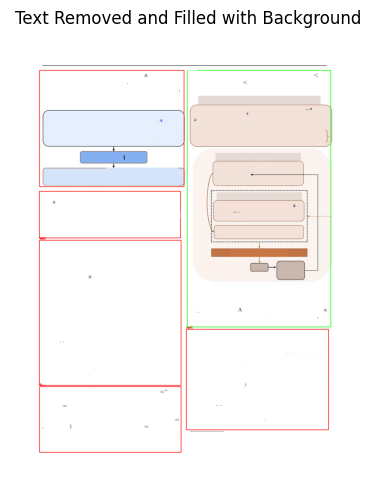

In [ ]:
import cv2
import numpy as np
import easyocr
import matplotlib.pyplot as plt
from collections import Counter

# Load EasyOCR Model
reader = easyocr.Reader(['en'], gpu=True)

# Load Image
image_path = "/content/output_bbox.png"  # Change this to your image path
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert to RGB

# Perform OCR Detection
results = reader.readtext(image)

# Process each bounding box
for (bbox, text, prob) in results:
    (top_left, top_right, bottom_right, bottom_left) = bbox
    x_min, y_min = map(int, top_left)
    x_max, y_max = map(int, bottom_right)

    # Extract the region inside the bounding box
    roi = image[y_min:y_max, x_min:x_max]

    # Convert ROI to HSV for better color analysis
    roi_hsv = cv2.cvtColor(roi, cv2.COLOR_RGB2HSV)

    # Reshape ROI to a list of pixels
    pixels = roi_hsv.reshape(-1, 3)

    # Filter out black text (V < 50 in HSV)
    filtered_pixels = [tuple(p) for p in pixels if p[2] > 50]  # Keep only non-black colors

    # Get the most common color inside the bbox
    if filtered_pixels:
        most_common_color = Counter(filtered_pixels).most_common(1)[0][0]
        most_common_rgb = cv2.cvtColor(np.uint8([[most_common_color]]), cv2.COLOR_HSV2RGB)[0][0]  # Convert back to RGB
    else:
        most_common_rgb = [255, 255, 255]  # Default to white if no colors found

    # Fill the detected text area with the majority background color
    image[y_min:y_max, x_min:x_max] = most_common_rgb

# Display the final result
plt.figure(figsize=(10, 6))
plt.imshow(image)
plt.title("Text Removed and Filled with Background")
plt.axis("off")
plt.show()



In [ ]:
!pip install reportlab

In [ ]:
import cv2
import easyocr
import numpy as np
from PIL import Image
from reportlab.pdfgen import canvas
from reportlab.lib.utils import simpleSplit
from collections import Counter
from pdf2docx import Converter

# Initialize EasyOCR Reader
reader = easyocr.Reader(['en'])

# Load Image
image_path = "/content/Blue and Gray Simple Professional CV Resume.jpg"
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert to RGB

# Perform OCR
results = reader.readtext(image)

# Process each bounding box
for (bbox, text, prob) in results:
    top_left, top_right, bottom_right, bottom_left = bbox
    x_min, y_min = map(int, top_left)
    x_max, y_max = map(int, bottom_right)

    # Extract the region inside the bounding box
    roi = image[y_min:y_max, x_min:x_max]

    # Convert ROI to HSV for better color analysis
    roi_hsv = cv2.cvtColor(roi, cv2.COLOR_RGB2HSV)

    # Reshape ROI to a list of pixels
    pixels = roi_hsv.reshape(-1, 3)

    # Filter out black text (V < 50 in HSV)
    filtered_pixels = [tuple(p) for p in pixels if p[2] > 50]  # Keep only non-black colors

    # Get the most common color inside the bbox
    if filtered_pixels:
        most_common_color = Counter(filtered_pixels).most_common(1)[0][0]
        most_common_rgb = cv2.cvtColor(np.uint8([[most_common_color]]), cv2.COLOR_HSV2RGB)[0][0]  # Convert back to RGB
    else:
        most_common_rgb = [255, 255, 255]  # Default to white if no colors found

    # Fill the detected text area with the majority background color
    image[y_min:y_max, x_min:x_max] = most_common_rgb

# Save Image Without Text
cleaned_image_path = "/content/cleaned_output.png"
cv2.imwrite(cleaned_image_path, cv2.cvtColor(image, cv2.COLOR_RGB2BGR))

# Load the cleaned image
img = Image.open(cleaned_image_path)

# Define A4 Page Size (in points)
A4_WIDTH, A4_HEIGHT = 595, 842  # A4 size in points

# Get Original Image Size
img_width, img_height = img.size

# Resize Image to Fit A4 Page (Maintain Aspect Ratio)
scale_factor = min(A4_WIDTH / img_width, A4_HEIGHT / img_height)
new_width = int(img_width * scale_factor)
new_height = int(img_height * scale_factor)

img = img.resize((new_width, new_height), Image.Resampling.LANCZOS)

# Save the resized image
resized_image_path = "/content/resized_output.png"
img.save(resized_image_path)

# Create PDF Canvas with A4 Size
pdf_path = "/content/output.pdf"
c = canvas.Canvas(pdf_path, pagesize=(A4_WIDTH, A4_HEIGHT))

# Calculate Offset to Center the Image
x_offset = (A4_WIDTH - new_width) // 2
y_offset = (A4_HEIGHT - new_height) // 2

# Paste the Resized Image (No Text)
c.drawImage(resized_image_path, x_offset, y_offset, width=new_width, height=new_height)

# Function to Fit Text Inside Bounding Box Correctly
def draw_wrapped_text(canvas, text, x, y, width, height, font_name="Helvetica"):
    """Dynamically fits text inside a bounding box by adjusting font size and wrapping text properly."""

    max_font_size = int(height * 0.8)  # Set font as 80% of bounding box height
    min_font_size = 6  # Minimum readable font size
    font_size = max_font_size

    while font_size >= min_font_size:
        canvas.setFont(font_name, font_size)
        wrapped_text = simpleSplit(text, font_name, font_size, width)

        # Check if text fits inside the bounding box
        text_height = len(wrapped_text) * (font_size + 2)  # Adding small spacing

        if text_height <= height:
            # Adjust Y to start from the bottom of the box
            start_y = y + height - text_height

            for i, line in enumerate(wrapped_text):
                line_y = start_y + (i * (font_size + 2))
                canvas.drawString(x, line_y, line)
            return

        # Reduce font size if text doesn't fit
        font_size -= 1

# Scale bounding boxes to match the resized image
scale_x = new_width / img_width
scale_y = new_height / img_height

# Draw Extracted Text Inside Bounding Boxes (Scaled)
for (bbox, text, prob) in results:
    top_left, top_right, bottom_right, bottom_left = bbox
    bbox_x = int(top_left[0] * scale_x) + x_offset
    bbox_y = int(top_left[1] * scale_y) + y_offset
    bbox_width = int((bottom_right[0] - top_left[0]) * scale_x)
    bbox_height = int((bottom_right[1] - top_left[1]) * scale_y)

    # Correct Y-position: Ensure text starts inside the bounding box
    corrected_y_pdf = A4_HEIGHT - (bbox_y + bbox_height)

    draw_wrapped_text(c, text, bbox_x, corrected_y_pdf, bbox_width, bbox_height)

# Save the PDF
c.save()

print(f"✅ PDF saved at: {pdf_path}")

# Convert PDF to Word (DOCX)
docx_path = "/content/output.docx"
cv = Converter(pdf_path)
cv.convert(docx_path, start=0, end=None)  # Convert entire PDF
cv.close()

print(f"✅ DOCX saved at: {docx_path}")


✅ PDF saved at: /content/output.pdf
✅ DOCX saved at: /content/output.docx


# Paddleocr

In [ ]:
!pip install paddleocr

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 3.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 544.7/544.7 kB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.9/161.9 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 297.8/297.8 kB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 969.6/969.6 kB 37.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 244.3/244.3 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 75.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 236.0/236.0 kB 15.9 MB/s eta 0:00:00
  Created wheel for fire: filename=fire-0.7.0-py3-none-any.whl size=114249 sha256=4297132ed6a9f96a880cdf99a1b5575beee008006c0d90d07c6a467c1e047766
  Stored in directory: /root/.cache/pip/wheels/46/54/24/1624fd5b8674eb1188623f7e8e17cdf7c0f6c24b609dfb8a89
Successfully built fire
  Attempting uninstall: albucore
    F

In [ ]:
!pip install paddlepaddle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 MB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 4.2 MB/s eta 0:00:00
  Attempting uninstall: opt-einsum
    Found existing installation: opt_einsum 3.4.0
    Uninstalling opt_einsum-3.4.0:
      Successfully uninstalled opt_einsum-3.4.0


In [ ]:
!pip install pdf2docx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.0/132.0 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.0/20.0 MB 78.1 MB/s eta 0:00:00


In [ ]:
!pip install reportlab

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 26.7 MB/s eta 0:00:00


In [ ]:
!pip install gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 MB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.1/322.1 kB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.9/94.9 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 95.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 4.0 MB/s eta 0:00:00
  Attempting uninstall: markupsafe
    Found existing installation: MarkupSafe 3.0.2
    Uninstalling MarkupSafe-3.0.2:
      Successfully uninstalled MarkupSafe-3.0.2


In [ ]:
import cv2
import numpy as np
from PIL import Image
from paddleocr import PaddleOCR
from reportlab.pdfgen import canvas
from reportlab.lib.utils import simpleSplit
from collections import Counter
from pdf2docx import Converter


In [ ]:
import cv2
import numpy as np
import os
from paddleocr import PaddleOCR
from collections import Counter
from PIL import Image
from reportlab.pdfgen import canvas
from reportlab.lib.utils import simpleSplit
from pdf2docx import Converter
from docx import Document

# Initialize PaddleOCR
ocr = PaddleOCR(lang='en')

# Load Image
image_path = "/content/Double_Column_Resume_Template_Enhancv_1_d747b76f51.png"
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert to RGB

# Perform OCR with PaddleOCR
results = ocr.ocr(image_path, cls=True)

# Process each bounding box and remove text
for res in results[0]:  # PaddleOCR output format
    bbox, (text, confidence) = res
    bbox = np.array(bbox, dtype=np.int32)

    x_min, y_min = bbox[0]
    x_max, y_max = bbox[2]

    # Extract the region inside the bounding box
    roi = image[y_min:y_max, x_min:x_max]

    # Convert ROI to HSV for better color analysis
    roi_hsv = cv2.cvtColor(roi, cv2.COLOR_RGB2HSV)

    # Reshape ROI to a list of pixels
    pixels = roi_hsv.reshape(-1, 3)

    # Filter out black text (V < 50 in HSV)
    filtered_pixels = [tuple(p) for p in pixels if p[2] > 50]

    # Get the most common color inside the bbox
    most_common_rgb = [255, 255, 255]  # Default to white if empty
    if filtered_pixels:
        most_common_color = Counter(filtered_pixels).most_common(1)[0][0]
        most_common_rgb = cv2.cvtColor(np.uint8([[most_common_color]]), cv2.COLOR_HSV2RGB)[0][0]

    # Fill the detected text area with the majority background color
    image[y_min:y_max, x_min:x_max] = most_common_rgb

# Save Image Without Text
cleaned_image_path = "/content/cleaned_output.png"
cv2.imwrite(cleaned_image_path, cv2.cvtColor(image, cv2.COLOR_RGB2BGR))

# Load the cleaned image
img = Image.open(cleaned_image_path)

# Define A4 Page Size (in points)
A4_WIDTH, A4_HEIGHT = 595, 842

# Get Original Image Size
img_width, img_height = img.size

# Resize Image to Fit A4 Page (Maintain Aspect Ratio)
scale_factor = min(A4_WIDTH / img_width, A4_HEIGHT / img_height)
new_width = int(img_width * scale_factor)
new_height = int(img_height * scale_factor)

img = img.resize((new_width, new_height), Image.Resampling.LANCZOS)

# Save the resized image
resized_image_path = "/content/resized_output.png"
img.save(resized_image_path)

# Create PDF Canvas with A4 Size
pdf_path = "/content/output.pdf"
c = canvas.Canvas(pdf_path, pagesize=(A4_WIDTH, A4_HEIGHT))

# Calculate Offset to Center the Image
x_offset = (A4_WIDTH - new_width) // 2
y_offset = (A4_HEIGHT - new_height) // 2

# Paste the Resized Image (No Text)
c.drawImage(resized_image_path, x_offset, y_offset, width=new_width, height=new_height)

# Function to Fit Text Inside Bounding Box Correctly
def draw_wrapped_text(canvas, text, x, y, width, height, font_name="Helvetica-Bold"):
    """Dynamically fits text inside a bounding box by adjusting font size and wrapping text properly."""
    max_font_size = int(height * 0.8)  # Set font as 80% of bounding box height
    min_font_size = 6  # Minimum readable font size
    font_size = max_font_size

    while font_size >= min_font_size:
        canvas.setFont(font_name, font_size)
        wrapped_text = simpleSplit(text, font_name, font_size, width)

        # Check if text fits inside the bounding box
        text_height = len(wrapped_text) * (font_size + 2)  # Adding small spacing

        if text_height <= height:
            start_y = y + height - text_height
            for i, line in enumerate(wrapped_text):
                line_y = start_y + (i * (font_size + 2))
                canvas.drawString(x, line_y, line)
            return
        font_size -= 1  # Decrease font size if text overflows

    # If text is still too large, use smallest font size
    canvas.setFont(font_name, min_font_size)
    wrapped_text = simpleSplit(text, font_name, min_font_size, width)
    start_y = y + height - (len(wrapped_text) * (min_font_size + 2))

    for i, line in enumerate(wrapped_text):
        line_y = start_y + (i * (min_font_size + 2))
        canvas.drawString(x, line_y, line)

# Scale bounding boxes to match the resized image
scale_x = new_width / img_width
scale_y = new_height / img_height

# Draw Extracted Text Inside Bounding Boxes (Scaled)
for res in results[0]:  # PaddleOCR output format
    bbox, (text, confidence) = res
    bbox = np.array(bbox, dtype=np.int32)

    bbox_x = int(bbox[0][0] * scale_x) + x_offset
    bbox_y = int(bbox[0][1] * scale_y) + y_offset
    bbox_width = int((bbox[2][0] - bbox[0][0]) * scale_x)
    bbox_height = int((bbox[2][1] - bbox[0][1]) * scale_y)

    corrected_y_pdf = A4_HEIGHT - (bbox_y + bbox_height)

    draw_wrapped_text(c, text, bbox_x, corrected_y_pdf, bbox_width, bbox_height)

# Save the PDF
c.save()
print(f"PDF saved at: {pdf_path}")

# Convert the Correct PDF to DOCX
docx_path = "/content/output.docx"
cv = Converter(pdf_path)
cv.convert(docx_path, start=0, end=None)  # Convert the full PDF to DOCX
cv.close()

print(f"DOCX saved at: {docx_path}")

[2025/03/06 00:12:15] ppocr DEBUG: Namespace(help='==SUPPRESS==', use_gpu=False, use_xpu=False, use_npu=False, use_mlu=False, ir_optim=True, use_tensorrt=False, min_subgraph_size=15, precision='fp32', gpu_mem=500, gpu_id=0, image_dir=None, page_num=0, det_algorithm='DB', det_model_dir='/root/.paddleocr/whl/det/en/en_PP-OCRv3_det_infer', det_limit_side_len=960, det_limit_type='max', det_box_type='quad', det_db_thresh=0.3, det_db_box_thresh=0.6, det_db_unclip_ratio=1.5, max_batch_size=10, use_dilation=False, det_db_score_mode='fast', det_east_score_thresh=0.8, det_east_cover_thresh=0.1, det_east_nms_thresh=0.2, det_sast_score_thresh=0.5, det_sast_nms_thresh=0.2, det_pse_thresh=0, det_pse_box_thresh=0.85, det_pse_min_area=16, det_pse_scale=1, scales=[8, 16, 32], alpha=1.0, beta=1.0, fourier_degree=5, rec_algorithm='SVTR_LCNet', rec_model_dir='/root/.paddleocr/whl/rec/en/en_PP-OCRv4_rec_infer', rec_image_inverse=True, rec_image_shape='3, 48, 320', rec_batch_num=6, max_text_length=25, rec_c

# Gradio

In [ ]:
import cv2
import numpy as np
import gradio as gr
from paddleocr import PaddleOCR
from collections import Counter
from PIL import Image
from reportlab.pdfgen import canvas
from pdf2docx import Converter
from docx import Document
from docx.shared import Inches

ocr = PaddleOCR(lang='en')

A4_WIDTH, A4_HEIGHT = 595, 842

def process_image(image):
    image_path = "uploaded_image.png"
    image.save(image_path)

    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    results = ocr.ocr(image_path, cls=True)

    for res in results[0]:
        bbox, (text, confidence) = res
        bbox = np.array(bbox, dtype=np.int32)

        x_min, y_min = bbox[0]
        x_max, y_max = bbox[2]

        roi = img[y_min:y_max, x_min:x_max]
        roi_hsv = cv2.cvtColor(roi, cv2.COLOR_RGB2HSV)
        pixels = roi_hsv.reshape(-1, 3)
        filtered_pixels = [tuple(p) for p in pixels if p[2] > 50]

        most_common_rgb = [255, 255, 255]
        if filtered_pixels:
            most_common_color = Counter(filtered_pixels).most_common(1)[0][0]
            most_common_rgb = cv2.cvtColor(np.uint8([[most_common_color]]), cv2.COLOR_HSV2RGB)[0][0]

        img[y_min:y_max, x_min:x_max] = most_common_rgb

    cleaned_image_path = "cleaned_output.png"
    cv2.imwrite(cleaned_image_path, cv2.cvtColor(img, cv2.COLOR_RGB2BGR))

    img_pil = Image.open(cleaned_image_path)
    img_width, img_height = img_pil.size
    scale_factor = min(A4_WIDTH / img_width, A4_HEIGHT / img_height)
    new_width = int(img_width * scale_factor)
    new_height = int(img_height * scale_factor)
    img_pil = img_pil.resize((new_width, new_height), Image.Resampling.LANCZOS)

    resized_image_path = "resized_output.png"
    img_pil.save(resized_image_path)

    pdf_path = "output.pdf"
    c = canvas.Canvas(pdf_path, pagesize=(A4_WIDTH, A4_HEIGHT))
    x_offset = (A4_WIDTH - new_width) // 2
    y_offset = (A4_HEIGHT - new_height) // 2
    c.drawImage(resized_image_path, x_offset, y_offset, width=new_width, height=new_height)

    scale_x = new_width / img_width
    scale_y = new_height / img_height

    for res in results[0]:
        bbox, (text, confidence) = res
        bbox = np.array(bbox, dtype=np.int32)

        bbox_x = int(bbox[0][0] * scale_x) + x_offset
        bbox_y = int(bbox[0][1] * scale_y) + y_offset
        bbox_width = int((bbox[2][0] - bbox[0][0]) * scale_x)
        bbox_height = int((bbox[2][1] - bbox[0][1]) * scale_y)
        corrected_y_pdf = A4_HEIGHT - (bbox_y + bbox_height)

        c.setFont("Helvetica-Bold", 8)
        c.drawString(bbox_x, corrected_y_pdf, text)

    c.save()

    docx_pdf_path = "output_from_pdf.docx"
    cv = Converter(pdf_path)
    cv.convert(docx_pdf_path, start=0, end=None)
    cv.close()

    docx_image_path = "output_cleaned_image.docx"
    doc = Document()
    doc.add_paragraph("Cleaned Image without Text:")
    doc.add_picture(cleaned_image_path, width=Inches(5))
    doc.save(docx_image_path)

    return cleaned_image_path, pdf_path, docx_pdf_path, docx_image_path

def gradio_interface(uploaded_image):
    return process_image(uploaded_image)

gr.Interface(
    fn=gradio_interface,
    inputs=gr.Image(type="pil", label="Upload Image"),
    outputs=[
        gr.File(label="Cleaned Image (Without Text)"),
        gr.File(label="Download PDF"),
        gr.File(label="Download DOCX (Correct Layout & Text from PDF)"),
        gr.File(label="Download DOCX (Only Layout, No Text)"),
    ],
    title="Editable Format Converter",
    description="Upload an image, remove text, and generate a PDF with text re-added. Also, get two DOCX versions: one from the PDF and one with only extracted layout.",
).launch()


[2025/03/06 02:05:09] ppocr DEBUG: Namespace(help='==SUPPRESS==', use_gpu=False, use_xpu=False, use_npu=False, use_mlu=False, ir_optim=True, use_tensorrt=False, min_subgraph_size=15, precision='fp32', gpu_mem=500, gpu_id=0, image_dir=None, page_num=0, det_algorithm='DB', det_model_dir='/root/.paddleocr/whl/det/en/en_PP-OCRv3_det_infer', det_limit_side_len=960, det_limit_type='max', det_box_type='quad', det_db_thresh=0.3, det_db_box_thresh=0.6, det_db_unclip_ratio=1.5, max_batch_size=10, use_dilation=False, det_db_score_mode='fast', det_east_score_thresh=0.8, det_east_cover_thresh=0.1, det_east_nms_thresh=0.2, det_sast_score_thresh=0.5, det_sast_nms_thresh=0.2, det_pse_thresh=0, det_pse_box_thresh=0.85, det_pse_min_area=16, det_pse_scale=1, scales=[8, 16, 32], alpha=1.0, beta=1.0, fourier_degree=5, rec_algorithm='SVTR_LCNet', rec_model_dir='/root/.paddleocr/whl/rec/en/en_PP-OCRv4_rec_infer', rec_image_inverse=True, rec_image_shape='3, 48, 320', rec_batch_num=6, max_text_length=25, rec_c

In [ ]:
!kill -9 -1

# new check out of the state art

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from paddleocr import PaddleOCR

# Load image
image_path = "/content/Double_Column_Resume_Template_Enhancv_1_d747b76f51.png"
image = cv2.imread(image_path)

# Initialize PaddleOCR
ocr = PaddleOCR(lang='en')

# Perform OCR
results = ocr.ocr(image_path, cls=True)

# Check the structure of results
print(results)  # Debugging: check how results are structured

# Draw bounding boxes
for res in results[0]:  # results[0] contains detected texts
    bbox, (text, confidence) = res  # Unpack correctly
    bbox = np.array(bbox, dtype=np.int32)  # Convert float to int

    # Draw rectangle
    cv2.polylines(image, [bbox], isClosed=True, color=(0, 255, 0), thickness=2)

    # Put text
    cv2.putText(image, text, tuple(bbox[0]), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)

# Convert BGR to RGB for Matplotlib
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Show image
plt.figure(figsize=(10, 6))
plt.imshow(image)
plt.axis("off")
plt.show()


[2025/03/06 00:04:14] ppocr DEBUG: Namespace(help='==SUPPRESS==', use_gpu=False, use_xpu=False, use_npu=False, use_mlu=False, ir_optim=True, use_tensorrt=False, min_subgraph_size=15, precision='fp32', gpu_mem=500, gpu_id=0, image_dir=None, page_num=0, det_algorithm='DB', det_model_dir='/root/.paddleocr/whl/det/en/en_PP-OCRv3_det_infer', det_limit_side_len=960, det_limit_type='max', det_box_type='quad', det_db_thresh=0.3, det_db_box_thresh=0.6, det_db_unclip_ratio=1.5, max_batch_size=10, use_dilation=False, det_db_score_mode='fast', det_east_score_thresh=0.8, det_east_cover_thresh=0.1, det_east_nms_thresh=0.2, det_sast_score_thresh=0.5, det_sast_nms_thresh=0.2, det_pse_thresh=0, det_pse_box_thresh=0.85, det_pse_min_area=16, det_pse_scale=1, scales=[8, 16, 32], alpha=1.0, beta=1.0, fourier_degree=5, rec_algorithm='SVTR_LCNet', rec_model_dir='/root/.paddleocr/whl/rec/en/en_PP-OCRv4_rec_infer', rec_image_inverse=True, rec_image_shape='3, 48, 320', rec_batch_num=6, max_text_length=25, rec_c

In [ ]:
import gc
del image, roi, roi_hsv, pixels, filtered_pixels  # Delete large variables
gc.collect()  # Force garbage collection


2085

In [ ]:
!kill -9 -1